In [33]:
import geopandas as gp
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy

### Victoria shapefile

In [5]:
states_file = '/g/data/jt48/aus-ref-clim-data-nci/shapefiles/data/aus_states_territories/aus_states_territories.shp'
states = gp.read_file(states_file)

In [6]:
states

,STE_NAME21,ABBREV,AREASQKM21,LOCI_URI21,geometry
0,New South Wales,NSW,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,Victoria,VIC,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,Queensland,QLD,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,South Australia,SA,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,Western Australia,WA,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,Tasmania,TAS,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,Northern Territory,NT,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,Australian Capital Territory,ACT,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,Other Territories,OT,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


In [11]:
victoria = states[states['STE_NAME21'] == 'Victoria']

### NRM regions shapefile

In [2]:
nrm_regions_file = '/g/data/jt48/aus-ref-clim-data-nci/shapefiles/data/nrm_regions/nrm_regions.shp'
nrm_regions = gp.read_file(nrm_regions_file)

In [3]:
nrm_regions

,SubClusNm,SubClusAb,ClusterNm,ClusterAb,SupClusNm,SupClusAb,geometry
0,Wet Tropics,WT,Wet Tropics,WT,Northern Australia,NA,"MULTIPOLYGON (((148.46142 -20.0668, 148.46219 ..."
1,Rangelands (North),RN,Rangelands,R,Rangelands,R,"MULTIPOLYGON (((114.17846 -21.80762, 114.18413..."
2,Monsoonal North (East),MNE,Monsoonal North,MN,Northern Australia,NA,"POLYGON ((146.29458 -18.89926, 146.29742 -18.9..."
3,Monsoonal North (West),MNW,Monsoonal North,MN,Northern Australia,NA,"POLYGON ((137.99467 -16.54112, 137.99491 -16.9..."
4,East Coast (South),ECS,East Coast,EC,Eastern Australia,EA,"POLYGON ((153.53441 -28.17701, 153.53442 -28.1..."
5,Central Slopes,CS,Central Slopes,CS,Eastern Australia,EA,"POLYGON ((147.957 -24.87855, 147.95711 -24.878..."
6,Murray Basin,MB,Murray Basin,MB,Southern Australia,SA,"POLYGON ((145.74765 -32.21733, 145.75054 -32.2..."
7,Southern and South Western Flatlands (West),SSWFW,Southern and South Western Flatlands,SSWF,Southern Australia,SA,"POLYGON ((124.21316 -33.03955, 124.21087 -33.0..."
8,Southern and South Western Flatlands (East),SSWFE,Southern and South Western Flatlands,SSWF,Southern Australia,SA,"POLYGON ((139.35429 -33.09761, 139.35429 -33.0..."
9,Southern Slopes (Vic/NSW East),SSVE,Southern Slopes,SS,Southern Australia,SA,"POLYGON ((150.99392 -34.22148, 150.9943 -34.22..."


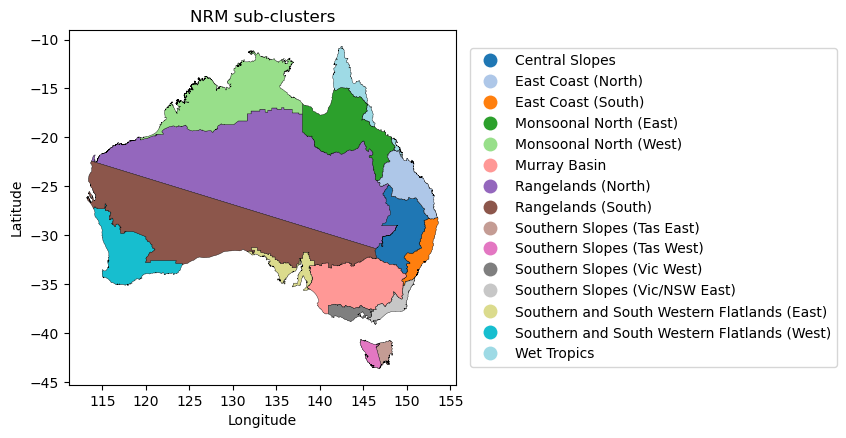

In [4]:
nrm_regions.plot(
    figsize=[5, 5],
    column='SubClusNm',
    cmap='tab20',
    legend=True,
    linewidth=0.25,
    edgecolor='black',
    legend_kwds={'loc': 'right', 'bbox_to_anchor': (2.0, 0.5)},
)
plt.title('NRM sub-clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [30]:
slopes_east = nrm_regions[nrm_regions['SubClusNm'] == 'Southern Slopes (Vic/NSW East)']
slopes_east_vic = slopes_east.overlay(victoria, how='intersection')

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/geopandas/geodataframe.py:2675: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4283
Right CRS: GEOGCS["GCS_GDA2020",DATUM["Geocentric_Datum_of_Au ...

  return geopandas.overlay(


In [28]:
slopes_west = nrm_regions[nrm_regions['SubClusNm'] == 'Southern Slopes (Vic West)']
slopes_west_vic = slopes_west.overlay(victoria, how='intersection')

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/geopandas/geodataframe.py:2675: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4283
Right CRS: GEOGCS["GCS_GDA2020",DATUM["Geocentric_Datum_of_Au ...

  return geopandas.overlay(


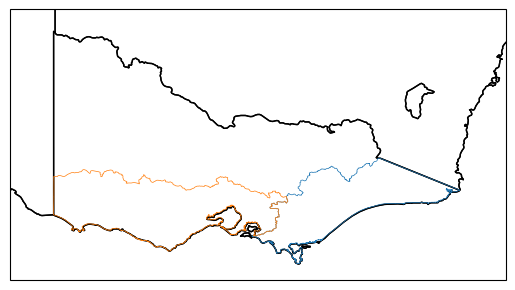

In [43]:
fig = plt.figure()
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())

ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.add_geometries(slopes_east_vic.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5, edgecolor='tab:blue')
ax1.add_geometries(slopes_west_vic.geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5,  edgecolor='tab:orange')
ax1.set_extent([140, 151, -33.5, -39.5], crs=ccrs.PlateCarree())

plt.show()